In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# 將專案 root 加入 python path（讓 src/ 可以 import）
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added:", project_root)
print("✓ Imports ready")

Project root added: C:\Users\USER\Desktop\2026_japan
✓ Imports ready


In [4]:
import pandas as pd

df_pred = pd.read_parquet("../data/predictions/convlstm_df_pred.parquet")


In [ ]:
import numpy as np
import pandas as pd

# df_pred 欄位: d, t, x, y, score, (count optional)
df = df_pred.copy()

# 型別保險
for c in ["d","t","x","y"]:
    df[c] = df[c].astype(int)
df["score"] = df["score"].astype(float)

# 聚合到每個格網
g = (df.groupby(["x","y"], as_index=False)
       .agg(mean_score=("score","mean"),
            max_score=("score","max"),
            std_score=("score","std"),
            n=("score","size")))

# Min-Max normalization 
mn, mx = g["mean_score"].min(), g["mean_score"].max()
eps = 1e-9
g["urban_score"] = (g["mean_score"] - mn) / (mx - mn + eps)

g.head()


,x,y,mean_score,max_score,std_score,n,urban_score
0,1,22,0.973182,1.014926,0.020987,9,0.006120
1,1,23,1.177460,2.258184,0.526102,11,0.010793
2,1,24,1.084786,2.330092,0.320807,243,0.008673
3,1,25,1.104661,2.228339,0.349343,35,0.009128
4,1,34,1.473461,2.331401,0.651960,19,0.017565


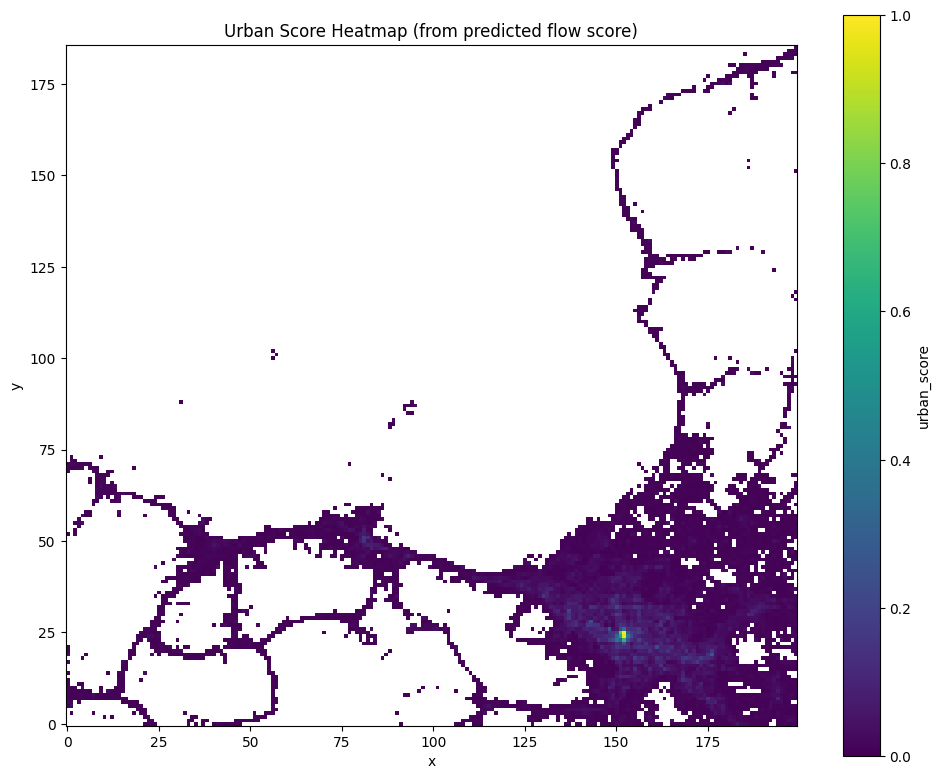

In [18]:
import matplotlib.pyplot as plt

# 轉成 2D 矩陣：row=y, col=x
mat = (g.pivot(index="y", columns="x", values="urban_score")
         .sort_index(axis=0)   # y 排序
         .sort_index(axis=1))  # x 排序
A = mat.values
A_90 = np.rot90(A, 3)
A_lr = np.fliplr(A_90)
plt.figure(figsize=(10, 8))
im = plt.imshow(A_lr, origin="lower", aspect="equal")
plt.colorbar(im, label="urban_score")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Urban Score Heatmap (from predicted flow score)")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

def synthesize_parking_lots(
    g, 
    seed=42,
    lambda_min=0.02,   # 郊區每格網平均 0.02 個（約 50 格出 1 個）
    lambda_max=0.35,   # 市區每格網平均 0.35 個（約 3 格出 1 個）
    gamma=1.8,         # >1 讓市區更集中
    city_cap_range=(15, 30), # 市區格數範圍
    suburb_cap_range=(60, 120), # 郊區格數範圍
    city_threshold=0.3,  # 超過當市區
    jitter=True
):
    rng = np.random.default_rng(seed) #可重現停車場資料

    grid = g[["x","y","urban_score"]].copy()
    u = grid["urban_score"].to_numpy()

    # 每格網的期望停車場數 
    lam = lambda_min + (lambda_max - lambda_min) * np.power(u, gamma)

    # 每格網用 Poisson 分布隨機產生要生成幾個停車場
    k = rng.poisson(lam)

    rows = []
    park_id = 0

    for (x, y, us, kk) in zip(grid["x"].to_numpy(), grid["y"].to_numpy(), u, k):
        if kk <= 0:
            continue

        is_city = (us >= city_threshold)

        # 容量範圍（市區/郊區）
        cap_lo, cap_hi = city_cap_range if is_city else suburb_cap_range

        for _ in range(kk):
            park_id += 1

            # 停車場座標：先用格網座標；可加 jitter 讓多個停車場在格網內隨機偏移而不重疊
            if jitter:
                px = x + rng.uniform(-0.35, 0.35)
                py = y + rng.uniform(-0.35, 0.35)
            else:
                px, py = float(x), float(y)

            capacity = int(rng.integers(cap_lo, cap_hi + 1))

            rows.append({
                "park_id": park_id,
                "grid_x": int(x),
                "grid_y": int(y),
                "park_x": float(px),
                "park_y": float(py),
                "urban_score": float(us),
                "is_city": int(is_city),
                "capacity": capacity
            })

    df_parks = pd.DataFrame(rows)
    return df_parks

city_q = 0.7
city_threshold = g["urban_score"].quantile(city_q)

df_parks = synthesize_parking_lots(g, seed=2026, city_threshold=city_threshold)
df_parks.head(), len(df_parks)
#df_parks.to_csv("sapporo_synthetic_parking_lots.csv", index=False)

(   park_id  grid_x  grid_y    park_x      park_y  urban_score  is_city  \
 0        1       1     185  0.933908  185.030703     0.026051        1   
 1        2       4     130  3.920186  129.930470     0.014798        0   
 2        3       4     137  4.005032  137.319110     0.012113        0   
 3        4       4     146  3.922324  146.111331     0.009512        0   
 4        5       4     159  4.228922  158.698902     0.005935        0   
 
    capacity  
 0        26  
 1        90  
 2        91  
 3       120  
 4        70  ,
 144)

In [39]:
# 市區/郊區數量對比
summary = (df_parks.groupby("is_city")
           .agg(n_parks=("park_id","count"),
                mean_cap=("capacity","mean"),
                med_cap=("capacity","median"),
                capacity=("capacity","sum"))
          )
summary['avg_cap'] = summary['capacity'] / summary['n_parks']
summary



,n_parks,mean_cap,med_cap,capacity,avg_cap
is_city,,,,,
0,98,90.357143,91.0,8855,90.357143
1,46,22.543478,22.0,1037,22.543478
